In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
# from tensorflow.python.client import device_lib
# import tensorflow
# print(tensorflow.config.list_physical_devices('CPU'))

In [ ]:
data = pd.read_csv("combined_data.csv")

# data.head()

data.tail()





,label,text
83442,0,tewk wrote patch was to large to attach so htt...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [18]:

data.label.value_counts()

label
1    43910
0    39538
Name: count, dtype: int64

C:\Users\ALee\AppData\Local\Temp\ipykernel_17700\2405554770.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label',data=data, palette='dark')


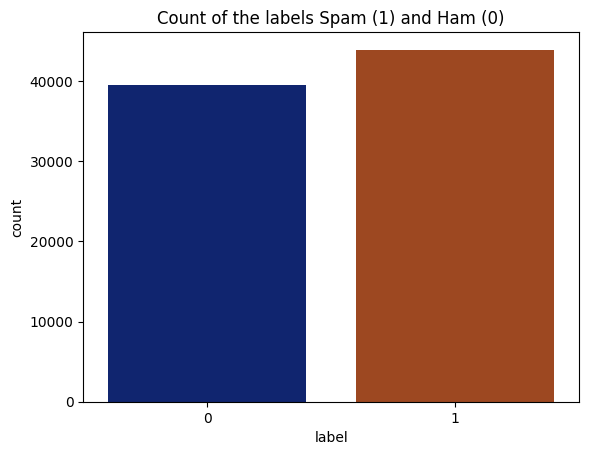

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


In [ ]:
sns.countplot(x='label',data=data, palette='dark')
plt.title('Count of the labels Spam (1) and Ham (0)')
plt.show() 

# print(sns.palettes.SEABORN_PALETTES.keys())

In [10]:
print(data.isnull().sum())
print(data.shape)
# Check for duplicates  
print(data.duplicated().sum())
# Drop duplicates if any
data.drop_duplicates(inplace=True)

label    0
text     0
dtype: int64
(83448, 2)
0


In [8]:
def len_info(text):
    l=text.split()
    l=len(l)
    return l 

In [5]:
data['len_text']=data['text'].apply(len_info)
data.head()

,label,text,len_text
0,1,ounce feather bowl hummingbird opec moment ala...,20
1,1,wulvob get your medircations online qnb ikud v...,103
2,0,computer connection from cnn com wednesday es...,337
3,1,university degree obtain a prosperous future m...,76
4,0,thanks for all your answers guys i know i shou...,222


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

def preprocessing(text):
    if not isinstance(text, str):
        return ""  # Handle non-string inputs
        

    text = text.lower()    

    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    
    tokens = word_tokenize(text)
    
    #Remove stopwords and perform stemming
    ps = PorterStemmer()
    sw = set(stopwords.words('english'))
    tokens = [ps.stem(word) for word in tokens if word not in sw and len(word) > 1]
    
    
    clean_text = ' '.join(tokens)
    
    return clean_text

# Now apply the function
data['clean_text'] = data['text'].apply(preprocessing)
data.head()

In [9]:
data['clean_text']=data['text'].apply(preprocessing)
data.head()

,label,text,len_text,clean_text
0,1,ounce feather bowl hummingbird opec moment ala...,20,ounc feather bowl hummingbird opec moment alab...
1,1,wulvob get your medircations online qnb ikud v...,103,wulvob get medirc onlin qnb ikud viagra escape...
2,0,computer connection from cnn com wednesday es...,337,comput connect cnn com wednesday escapenumb ma...
3,1,university degree obtain a prosperous future m...,76,univers degre obtain prosper futur money earn ...
4,0,thanks for all your answers guys i know i shou...,222,thank answer guy know check rsync manual would...


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from sklearn.model_selection import train_test_split

In [11]:
voc_size=1000
model=Sequential()
model.add(Embedding(voc_size,40))
model.add(LSTM(100))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [12]:
tokenizer = Tokenizer(num_words=100)
tokenizer.fit_on_texts(data['clean_text'].values)

In [13]:
sequences = tokenizer.texts_to_sequences(data['clean_text'].values)
maxlen = 100
x = pad_sequences(sequences,padding='post',maxlen=maxlen)
y=data['label']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
print('Train text shape: ',x_train.shape)
print('Train label shape: ',y_train.shape)

Train text shape:  (66758, 100)
Train label shape:  (66758,)


In [ ]:
op=model.fit(x_train,y_train,validation_data=(x_test,y_test),batch_size=64,epochs=5)

Epoch 1/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 155s 72ms/step - accuracy: 0.6772 - loss: 0.5663 - val_accuracy: 0.8687 - val_loss: 0.3426
Epoch 2/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 139s 67ms/step - accuracy: 0.8811 - loss: 0.3079 - val_accuracy: 0.9017 - val_loss: 0.2383
Epoch 3/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 165s 79ms/step - accuracy: 0.9098 - loss: 0.2245 - val_accuracy: 0.9175 - val_loss: 0.2055
Epoch 4/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 149s 71ms/step - accuracy: 0.9231 - loss: 0.1966 - val_accuracy: 0.9271 - val_loss: 0.1774
Epoch 5/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 160s 76ms/step - accuracy: 0.9310 - loss: 0.1741 - val_accuracy: 0.9325 - val_loss: 0.1688


In [ ]:
# plt.plot(op.history['accuracy'])
# plt.plot(op.history['val_accuracy'])
# plt.title('Model Accuracy')
# plt.xlabel('epoch')
# plt.ylabel('accuracy')
# plt.show()

In [25]:
user=[''' 
Dear Students,Please find attached the FYP-2 Midterm Evaluation form along with the FYP-2 Evaluation Schedule for Spring 2025.You are required to bring the following on the day of your evaluation:A draft of your report, duly signed by your supervisor and respective coordinators. Three (3) copies of the FYP-2 Midterm Evaluation form. 
Note
Ensure you arrive on time for your evaluation.
Formal dress code is mandatory.
Follow the order of group evaluations as listed in the provided schedule.
       
''']
test_sequences = tokenizer.texts_to_sequences(user)
a=pad_sequences(test_sequences,padding='post',maxlen=100)

res=model.predict(a)

if res>0.5:
    print(f'spam:{res}')

else:
    print(f'not a spam:{res}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
not a spam:[[0.18641986]]


In [25]:
model.save('lstm_model.h5')
print('Model Saved Successfully')

Model Saved Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

import re
import nltk
from nltk.stem import PorterStemmer  
from nltk.corpus import stopwords

In [ ]:
ps=PorterStemmer()
sw=stopwords.words('english')

voc_size=1000

data = pd.read_csv("combined_data.csv")
# data.head()

# def preprocessing(text):
#     c_text=text.split()
#     c_text=[ps.stem(word) for word in c_text if word not in sw ]
#     c_text=' '.join(c_text)
#     return c_text

# data['clean_text']=data['text'].apply(preprocessing)
# data.head()

In [3]:
# # Eval your model

tokenizer = Tokenizer(num_words=100)
# tokenizer.fit_on_texts(data['clean_text'].values)

# sequences = tokenizer.texts_to_sequences(data['clean_text'].values)
# maxlen = 100
# x = pad_sequences(sequences,padding='post',maxlen=maxlen)
# y=data['label']

# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# loss, acc = model.evaluate(x_test, y_test, verbose=2)
# print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

In [4]:
from tensorflow.keras.models import load_model

# Load the complete model
model = load_model('lstm_model.h5')

print("Model (architecture + weights) successfully loaded!")

Model (architecture + weights) successfully loaded!


In [ ]:
user=[''' 
You won a lottery. Claim your money now.
''']
test_sequences = tokenizer.texts_to_sequences(user)
a=pad_sequences(test_sequences,padding='post',maxlen=100)

res=model.predict(a)

if res>0.5:
    print(f'spam:{res}')

else:
    print(f'not a spam:{res}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
spam:[[0.72438526]]


In [6]:
import h5py

with h5py.File('lstm_model.h5', 'r') as f:
    print("Keys in the HDF5 file:", list(f.keys()))
    for key in f.keys():
        print(key, ":", list(f[key].keys()))

Keys in the HDF5 file: ['model_weights', 'optimizer_weights']
model_weights : ['dense_1', 'embedding_1', 'lstm_1', 'top_level_model_weights']
optimizer_weights : ['adam']
